# Synthetic Data Validation: Geometric Diagnostics vs Known True k₀

**Goal**: Verify that the 9 empirical findings from the real-data report reproduce
when we control the true factor rank k₀.

**Findings to validate**:
1. Sharpe ↑ in P (saturates ~4096) — KMZ Theorem 1
2. OOS R² ↑ in P (benign overfitting)
3. Spectral gap cliff at k₀ — Theorem 6.1(iii)
4. Low drift anisotropy ρ_θ → high Sharpe — Theorem 6.1(i)
5. All metrics ↑ in z — ridge–curvature chain
6. z=0 never finds optimal k — flat Hessian
7. d_proj ↓ in k at z=0 — Theorem 6.1(i)
8. Moderate d_proj is optimal (Goldilocks zone)
9. High Sharpe with erank collapse at k > k₀

**Strategy**: 3 focused sweeps instead of full Cartesian product:
- **Sweep A** (P=1024, k×z): findings 3,5,6,7,8,9 — ~24 jobs
- **Sweep B** (k∈{12,24}, P×z): findings 1,2 — ~12 jobs
- **Sweep C** (P=1024, z∈{10,50}, all k): finding 4 (anisotropy) — covered by A

In [3]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

# Add the project root so "from src.xxx" imports work
PROJECT_ROOT = os.path.dirname(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.rff import RandomFourierFeatures
from src.generate_synthetic_panel import generate_synthetic_panel
from src._grass_worker import (
    build_rff_inputs, build_jobs, run_sweep, aggregate, make_results_df,
    _z_label,
)

print('Imports OK')

Imports OK


## 1. Generate synthetic panel with known true k₀ = 12

In [4]:
TRUE_K0 = 12

df_synth, truth, char_cols = generate_synthetic_panel(
    T   = 360,           # 30 years monthly
    N   = 50,            # assets (matches real-data top-50)
    m   = 30,            # raw characteristics
    k0  = TRUE_K0,       # TRUE factor rank
    seed = 42,
    # Two-parameter eigenvalue decay: lambda_j = snr_base * decay^(j-1) + sigma^2
    # With defaults: lambda_1=6.0, lambda_6=2.87, lambda_12=1.60 (all above sigma^2=1)
    snr_base         = 5.0,
    eigenvalue_decay  = 0.82,
    sigma_eps         = 1.0,
    # Factor dynamics
    factor_ar1        = 0.5,
    factor_vol        = 0.3,
    # Subspace drift calibrated from real data d_proj ~ 0.6 at (k=12, z=50, P=1024)
    w_drift_scale     = None,    # auto-calibrate
    target_dproj      = 0.6,
    # Characteristics and noise
    z_corr            = 0.3,
    hetero_strength   = 0.3,
)

# Shared constants
NUM_FACTORS_LIST = [4, 8, 12, 16, 20, 24, 28, 32]
GAMMA      = 0.25
WINDOW_LEN = 24
NUM_ITER_RFF = 1   # single RFF seed — halves compute

# Dense char matrix for RFF
X_chars = (
    df_synth[char_cols]
    .apply(lambda s: s.fillna(s.mean()), axis=0)
    .astype(np.float64)
)

print(f"Panel shape      : {df_synth.shape}")
print(f"Date range       : {df_synth.index.get_level_values('date').min().date()} -> "
      f"{df_synth.index.get_level_values('date').max().date()}")
print(f"Assets           : {df_synth.index.get_level_values('permno').nunique()}")
print(f"True k0          : {truth['true_k0']}")
print(f"Signal lambdas   : {np.round(truth['signal_eigenvalues'], 3)}")
print(f"w_drift_scale    : {truth['w_drift_scale']:.5f} (calibrated from target_dproj={truth['params']['target_dproj']})")
print(f"X_chars shape    : {X_chars.shape}")

Panel shape      : (18000, 32)
Date range       : 1994-01-01 -> 2023-12-01
Assets           : 50
True k0          : 12
Signal lambdas   : [6.    5.1   4.362 3.757 3.261 2.854 2.52  2.246 2.022 1.838 1.687 1.564]
w_drift_scale    : 0.02500 (calibrated from target_dproj=0.6)
X_chars shape    : (18000, 30)


---
## 2. Sweep A — Fix P=1024, sweep k x z

**Jobs**: 8 k-values x 3 z-values x 1 seed = **24 jobs**

Validates findings 3, 4, 5, 6, 7, 8, 9

In [3]:
P_A = [1024]
K_A = NUM_FACTORS_LIST
Z_A = [0, 10, 50]

rff_A = build_rff_inputs(X_chars, df_synth, P_A, NUM_ITER_RFF, GAMMA, RandomFourierFeatures)
jobs_A = build_jobs(rff_A, K_A, P_A, Z_A, NUM_ITER_RFF, WINDOW_LEN)
print(f"Sweep A: {len(jobs_A)} jobs (P=1024, k x z)")

raw_A = run_sweep(jobs_A, verbose=True)
agg_A = aggregate(raw_A)
df_A  = make_results_df(agg_A)

print(f"\nSweep A done. Shape: {df_A.shape}")
df_A[['avg_sharpe', 'avg_spectral_gap', 'avg_erank', 'avg_subspace_stability']].round(4)

Sweep A: 24 jobs (P=1024, k x z)
Dispatching 24 jobs across 7 workers (cost range 8192–185364, LPT order) ...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   1 out of  24 | elapsed: 25.3min remaining: 581.8min
[Parallel(n_jobs=7)]: Done   4 out of  24 | elapsed: 89.2min remaining: 446.2min
[Parallel(n_jobs=7)]: Done   7 out of  24 | elapsed: 226.2min remaining: 549.3min
[Parallel(n_jobs=7)]: Done  10 out of  24 | elapsed: 239.9min remaining: 335.9min
[Parallel(n_jobs=7)]: Done  13 out of  24 | elapsed: 269.2min remaining: 227.8min
[Parallel(n_jobs=7)]: Done  16 out of  24 | elapsed: 317.8min remaining: 158.9min
[Parallel(n_jobs=7)]: Done  19 out of  24 | elapsed: 338.3min remaining: 89.0min
[Parallel(n_jobs=7)]: Done  22 out of  24 | elapsed: 375.9min remaining: 34.2min



Sweep A done. Shape: (24, 9)


[Parallel(n_jobs=7)]: Done  24 out of  24 | elapsed: 383.9min finished


avg_sharpe  avg_spectral_gap  avg_erank  \
k  P    z                                                  
4  1024 z=0e+00      0.0265            0.3202     3.6591   
        z=1e+01      0.1836            0.7169     3.9641   
        z=5e+01      0.3860            0.6952     3.9565   
8  1024 z=0e+00      0.4896            0.1136     6.5518   
        z=1e+01      0.5682            0.4181     7.6647   
        z=5e+01      0.6363            0.4220     7.6672   
12 1024 z=0e+00      0.5180            0.0382     8.9780   
        z=1e+01      0.7318            0.2780    11.0687   
        z=5e+01      0.6713            0.2962    11.1162   
16 1024 z=0e+00      0.6462            0.0158    10.7972   
        z=1e+01      0.6685            0.1828    14.2030   
        z=5e+01      0.6502            0.2262    14.3844   
20 1024 z=0e+00      0.5156            0.0042    12.2423   
        z=1e+01      0.6654            0.0900    16.9558   
        z=5e+01      0.6106            0.1729    17.4437   
24 1024 z=0e+00      0.6448            0.0002    13.5286   
        z=1e+01      0.6890            0.0088    18.8906   
        z=5e+01      0.6413            0.1144    19.9755   
28 1024 z=0e+00      0.4400            0.0000    14.2673   
        z=1e+01      0.6995            0.0000    19.5351   
        z=5e+01      0.6416            0.0000    19.9783   
32 1024 z=0e+00      0.3114            0.0000    15.1302   
        z=1e+01      0.6922            0.0000    19.7265   
        z=5e+01      0.6416            0.0000    19.9784   

                 avg_subspace_stability  
k  P    z                                
4  1024 z=0e+00                  0.4835  
        z=1e+01                  1.1819  
        z=5e+01                  1.3148  
8  1024 z=0e+00                  0.4526  
        z=1e+01                  1.2652  
        z=5e+01                  1.5320  
12 1024 z=0e+00                  0.3905  
        z=1e+01                  1.3080  
        z=5e+01                  1.6214  
16 1024 z=0e+00                  0.3141  
        z=1e+01                  1.3464  
        z=5e+01                  1.6945  
20 1024 z=0e+00                  0.2636  
        z=1e+01                  1.3774  
        z=5e+01                  1.7350  
24 1024 z=0e+00                  0.2088  
        z=1e+01                  1.3743  
        z=5e+01                  1.4225  
28 1024 z=0e+00                  0.1551  
        z=1e+01                  1.3602  
        z=5e+01                  1.4447  
32 1024 z=0e+00                  0.1182  
        z=1e+01                  1.3438  
        z=5e+01                  1.4511

### Sweep A plots: Finding 3 — Spectral gap cliff at k0

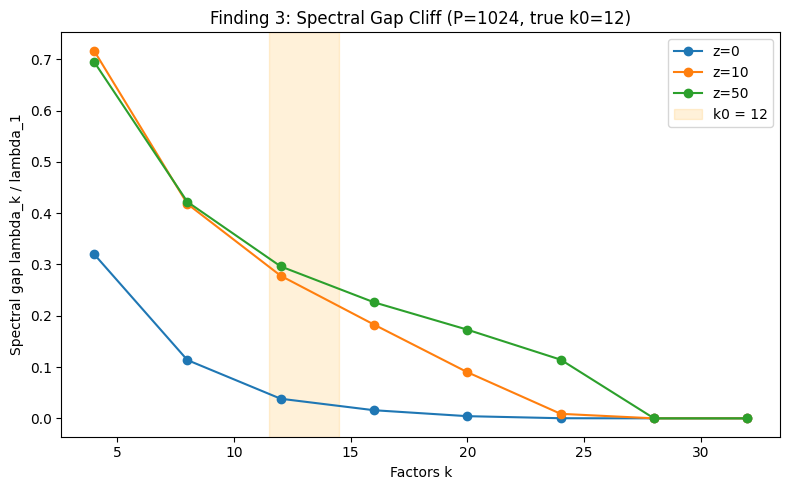

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
for z_val in Z_A:
    z_lab = _z_label(z_val)
    try:
        sub = df_A.xs((1024, z_lab), level=('P', 'z'))
        ax.plot(sub.index, sub['avg_spectral_gap'], 'o-', label=f'z={z_val}')
    except KeyError:
        pass

ax.axvspan(TRUE_K0 - 0.5, TRUE_K0 + 2.5, alpha=0.15, color='orange', label=f'k0 = {TRUE_K0}')
ax.set_xlabel('Factors k')
ax.set_ylabel('Spectral gap lambda_k / lambda_1')
ax.set_title(f'Finding 3: Spectral Gap Cliff (P=1024, true k0={TRUE_K0})')
ax.legend()
plt.tight_layout()
plt.show()

### Sweep A plots: Finding 5 — All metrics co-move with z

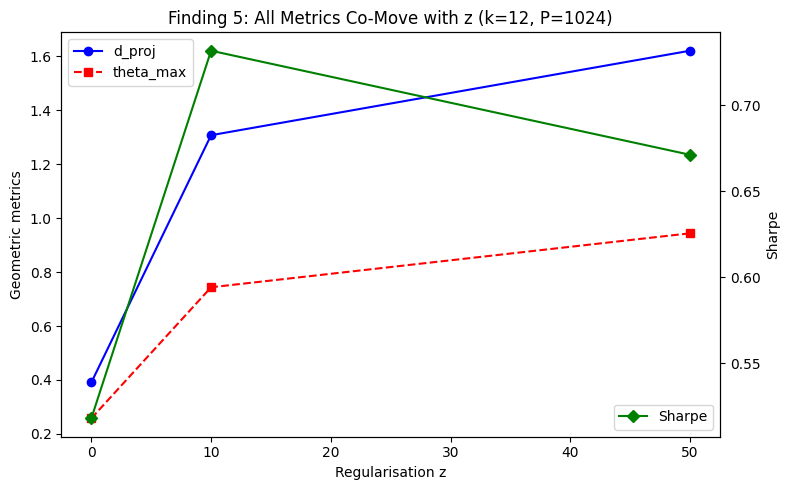

In [5]:
k_plot = TRUE_K0
P_plot = 1024

metrics_z = []
for z_val in Z_A:
    z_lab = _z_label(z_val)
    try:
        row = df_A.loc[(k_plot, P_plot, z_lab)]
        metrics_z.append({
            'z': z_val,
            'Sharpe': row['avg_sharpe'],
            'd_proj': row['avg_subspace_stability'],
            'theta_max': row['avg_max_principal_angle'],
            'erank': row['avg_erank'],
        })
    except KeyError:
        pass

df_z = pd.DataFrame(metrics_z).set_index('z')
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(df_z.index, df_z['d_proj'], 'o-b', label='d_proj')
ax1.plot(df_z.index, df_z['theta_max'], 's--r', label='theta_max')
ax2.plot(df_z.index, df_z['Sharpe'], 'D-g', label='Sharpe')

ax1.set_xlabel('Regularisation z')
ax1.set_ylabel('Geometric metrics')
ax2.set_ylabel('Sharpe')
ax1.set_title(f'Finding 5: All Metrics Co-Move with z (k={k_plot}, P={P_plot})')
ax1.legend(loc='upper left'); ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Sweep A plots: Finding 7 — d_proj decays with k at z=0

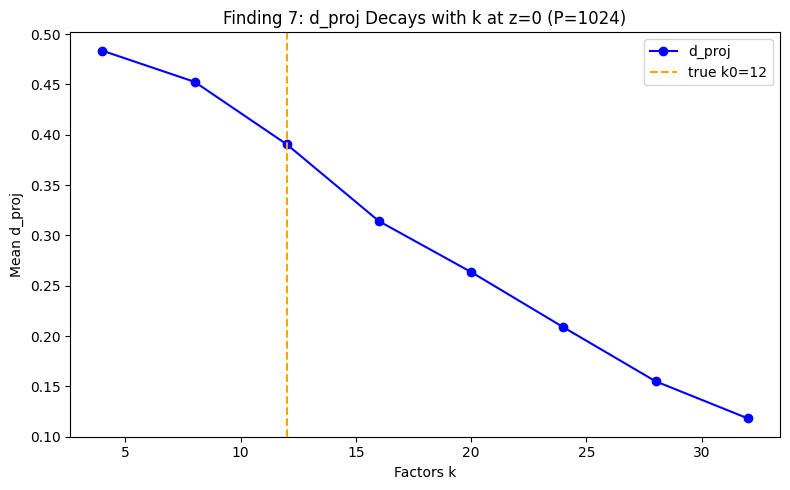

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
z_lab = _z_label(0)

try:
    sub = df_A.xs((1024, z_lab), level=('P', 'z'))
    ax.plot(sub.index, sub['avg_subspace_stability'], 'o-b', label='d_proj')
    ax.set_xlabel('Factors k')
    ax.set_ylabel('Mean d_proj')
    ax.axvline(TRUE_K0, ls='--', c='orange', label=f'true k0={TRUE_K0}')
    ax.set_title(f'Finding 7: d_proj Decays with k at z=0 (P=1024)')
    ax.legend()
except KeyError:
    print('No z=0 data.')

plt.tight_layout()
plt.show()

### Sweep A plots: Finding 6 — z=0 erratic vs z>0 clean peaks

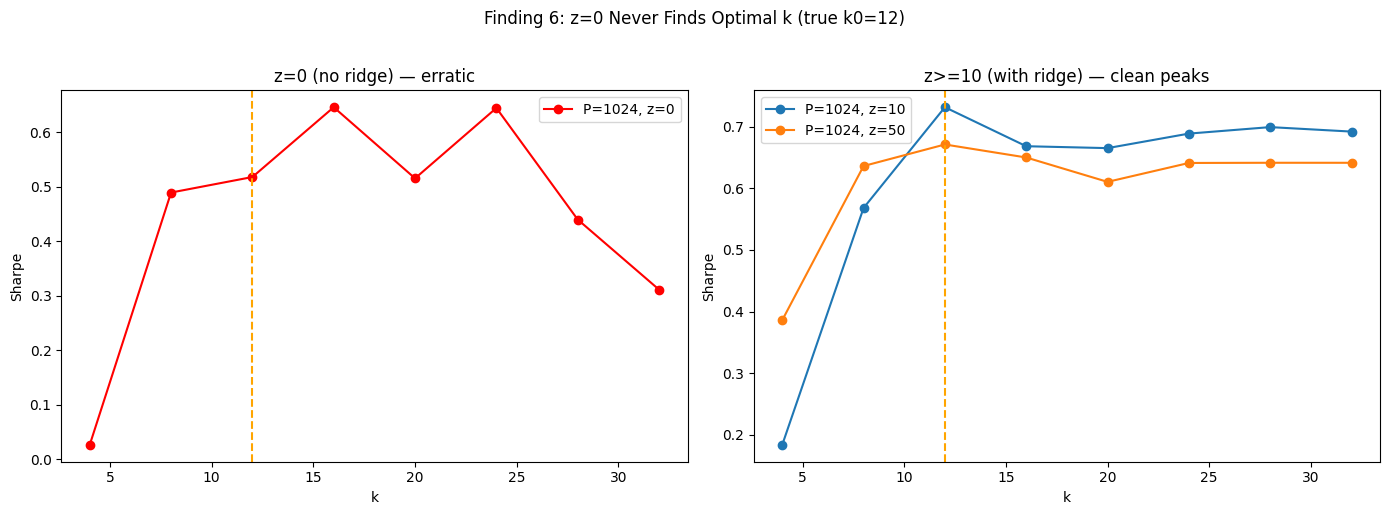

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: z=0 erratic
z_lab0 = _z_label(0)
try:
    sub = df_A.xs((1024, z_lab0), level=('P', 'z'))
    axes[0].plot(sub.index, sub['avg_sharpe'], 'o-r', label='P=1024, z=0')
except KeyError:
    pass
axes[0].set_title('z=0 (no ridge) — erratic')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Sharpe')
axes[0].axvline(TRUE_K0, ls='--', c='orange')
axes[0].legend()

# Right: z>0 clean
for z_val in [10, 50]:
    z_lab = _z_label(z_val)
    try:
        sub = df_A.xs((1024, z_lab), level=('P', 'z'))
        axes[1].plot(sub.index, sub['avg_sharpe'], 'o-', label=f'P=1024, z={z_val}')
    except KeyError:
        pass
axes[1].set_title('z>=10 (with ridge) — clean peaks')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Sharpe')
axes[1].axvline(TRUE_K0, ls='--', c='orange')
axes[1].legend()

plt.suptitle(f'Finding 6: z=0 Never Finds Optimal k (true k0={TRUE_K0})', y=1.02)
plt.tight_layout()
plt.show()

### Sweep A plots: Finding 9 — erank collapse at k > k0

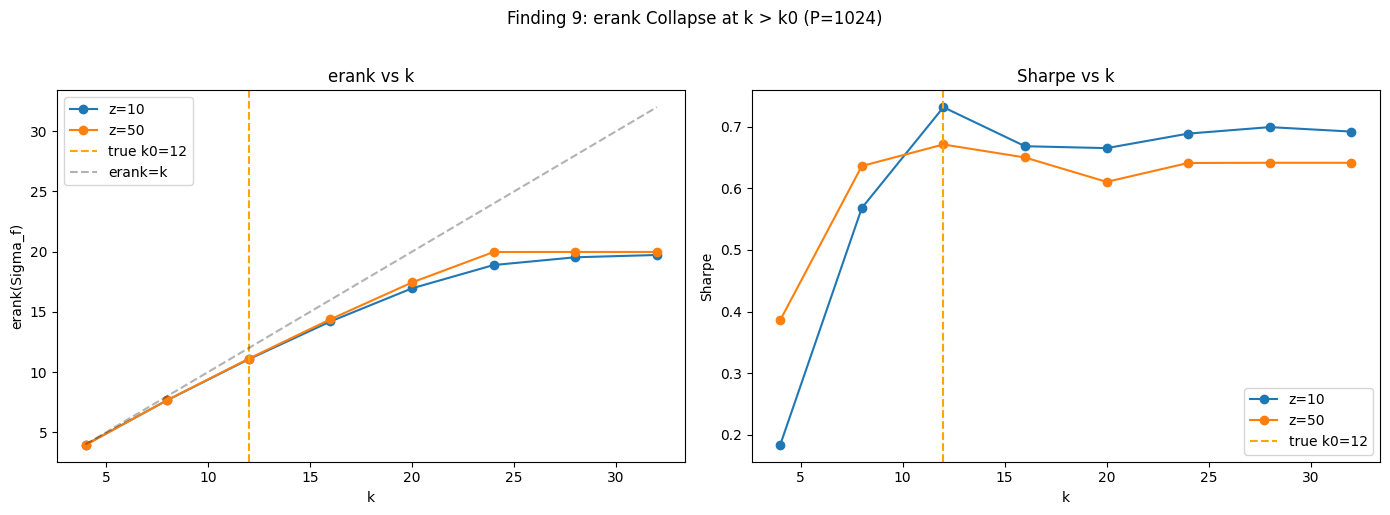

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for z_val in [10, 50]:
    z_lab = _z_label(z_val)
    try:
        sub = df_A.xs((1024, z_lab), level=('P', 'z'))
        axes[0].plot(sub.index, sub['avg_erank'], 'o-', label=f'z={z_val}')
        axes[1].plot(sub.index, sub['avg_sharpe'], 'o-', label=f'z={z_val}')
    except KeyError:
        pass

axes[0].axvline(TRUE_K0, ls='--', c='orange', label=f'true k0={TRUE_K0}')
axes[0].plot(K_A, K_A, 'k--', alpha=0.3, label='erank=k')
axes[0].set_xlabel('k'); axes[0].set_ylabel('erank(Sigma_f)')
axes[0].set_title('erank vs k'); axes[0].legend()

axes[1].axvline(TRUE_K0, ls='--', c='orange', label=f'true k0={TRUE_K0}')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Sharpe')
axes[1].set_title('Sharpe vs k'); axes[1].legend()

plt.suptitle(f'Finding 9: erank Collapse at k > k0 (P=1024)', y=1.02)
plt.tight_layout()
plt.show()

### Sweep A plots: Matched-pair comparison z=0 vs z=10

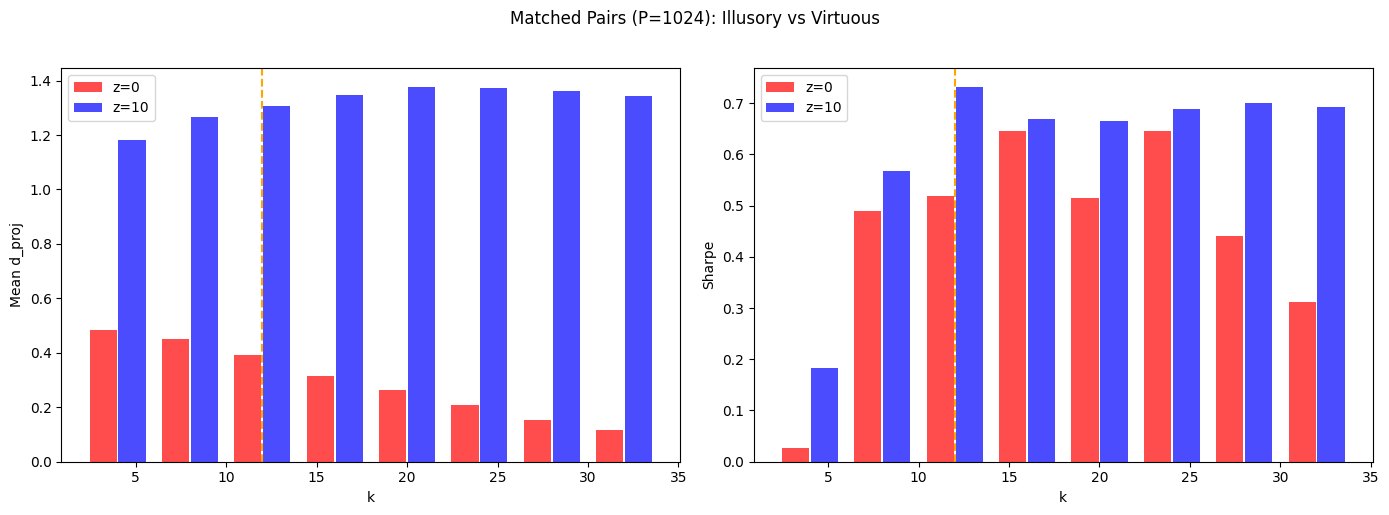

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
z0_lab  = _z_label(0)
z10_lab = _z_label(10)

bar_w = 1.5
for metric, ax_i, ylabel in [
    ('avg_subspace_stability', axes[0], 'Mean d_proj'),
    ('avg_sharpe', axes[1], 'Sharpe'),
]:
    for z_lab, color, label, offset in [
        (z0_lab,  'red',  'z=0',  -0.8),
        (z10_lab, 'blue', 'z=10',  0.8),
    ]:
        try:
            sub = df_A.xs((1024, z_lab), level=('P', 'z'))
            ax_i.bar(sub.index + offset, sub[metric],
                     width=bar_w, color=color, alpha=0.7, label=label)
        except KeyError:
            pass
    ax_i.axvline(TRUE_K0, ls='--', c='orange')
    ax_i.set_xlabel('k'); ax_i.set_ylabel(ylabel); ax_i.legend()

plt.suptitle(f'Matched Pairs (P=1024): Illusory vs Virtuous', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Sweep B — Fix k in {12, 24}, sweep P x z

**Jobs**: 2 k-values x 3 P-values x 2 z-values x 1 seed = **12 jobs**

Validates findings 1, 2 (Sharpe and R2 monotonically increase with P)

In [10]:
P_B = [256, 1024, 4096]
K_B = [TRUE_K0, 24]         # at k0 and past the cliff
Z_B = [10, 50]              # virtuous only (z=0 is noise here)

rff_B = build_rff_inputs(X_chars, df_synth, P_B, NUM_ITER_RFF, GAMMA, RandomFourierFeatures)
jobs_B = build_jobs(rff_B, K_B, P_B, Z_B, NUM_ITER_RFF, WINDOW_LEN)
print(f"Sweep B: {len(jobs_B)} jobs (k in {K_B}, P x z)")

raw_B = run_sweep(jobs_B, verbose=True)
agg_B = aggregate(raw_B)
df_B  = make_results_df(agg_B)

print(f"\nSweep B done. Shape: {df_B.shape}")
df_B[['avg_sharpe', 'avg_r2_oos']].round(4)

Sweep B: 12 jobs (k in [12, 24], P x z)
Dispatching 12 jobs across 7 workers (cost range 10642–481589, LPT order) ...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   1 out of  12 | elapsed: 113.2min remaining: 1244.7min
[Parallel(n_jobs=7)]: Done   3 out of  12 | elapsed: 132.4min remaining: 397.2min
[Parallel(n_jobs=7)]: Done   5 out of  12 | elapsed: 209.8min remaining: 293.7min
[Parallel(n_jobs=7)]: Done   7 out of  12 | elapsed: 254.1min remaining: 181.5min
[Parallel(n_jobs=7)]: Done   9 out of  12 | elapsed: 255.5min remaining: 85.2min
[Parallel(n_jobs=7)]: Done  12 out of  12 | elapsed: 272.7min finished



Sweep B done. Shape: (12, 9)


avg_sharpe  avg_r2_oos
k  P    z                              
12 256  z=1e+01      0.5739     -0.0190
        z=5e+01      0.5620     -0.0093
   1024 z=1e+01      0.7176     -0.0070
        z=5e+01      0.6693     -0.0065
   4096 z=1e+01      0.6933     -0.0075
        z=5e+01      0.6025     -0.0079
24 256  z=1e+01      0.6387     -0.0075
        z=5e+01      0.6331     -0.0040
   1024 z=1e+01      0.6839     -0.0019
        z=5e+01      0.6429     -0.0016
   4096 z=1e+01      0.7554     -0.0031
        z=5e+01      0.6799     -0.0011

### Sweep B plots: Finding 1 & 2 — Sharpe & R2 increase with P

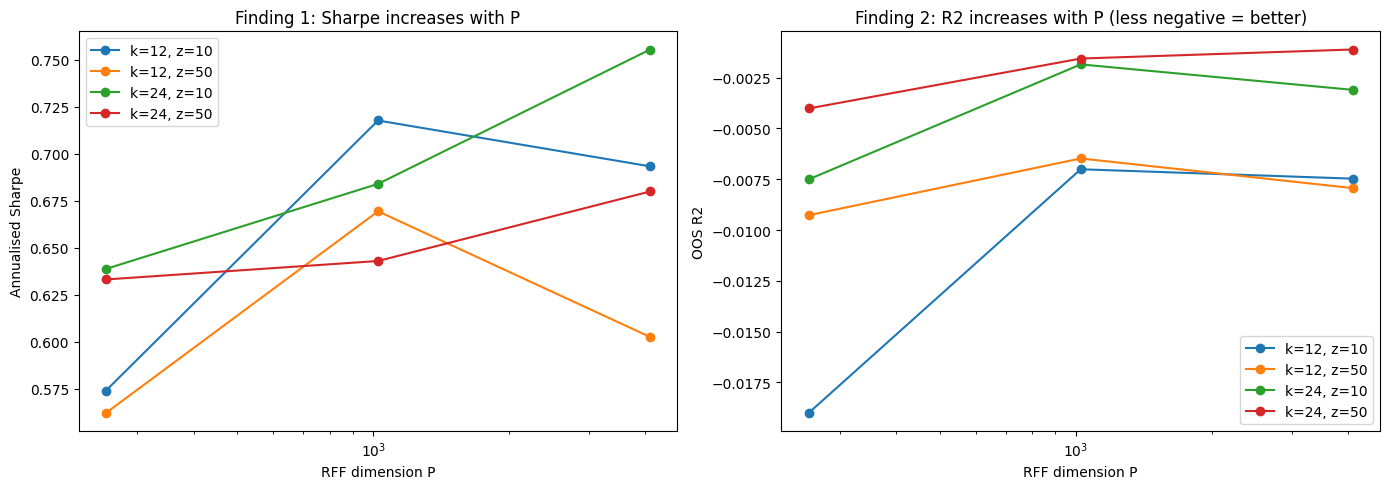

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for k_val in K_B:
    for z_val in Z_B:
        z_lab = _z_label(z_val)
        try:
            sub = df_B.xs(z_lab, level='z').xs(k_val, level='k')
            axes[0].plot(sub.index, sub['avg_sharpe'], 'o-',
                         label=f'k={k_val}, z={z_val}')
            axes[1].plot(sub.index, sub['avg_r2_oos'], 'o-',
                         label=f'k={k_val}, z={z_val}')
        except KeyError:
            pass

axes[0].set_xlabel('RFF dimension P'); axes[0].set_ylabel('Annualised Sharpe')
axes[0].set_title('Finding 1: Sharpe increases with P'); axes[0].legend()
axes[0].set_xscale('log')

axes[1].set_xlabel('RFF dimension P'); axes[1].set_ylabel('OOS R2')
axes[1].set_title('Finding 2: R2 increases with P (less negative = better)'); axes[1].legend()
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

## 4. Sweep C


In [ ]:
# ============================================================
# Sweep C — Smoother z curve (Finding 5: metrics co-move with z)
# Fix k=12, P=1024, sweep z with finer resolution
# Jobs: 1 k × 7 z × 1 seed = 7 jobs (all fast, P=1024)
# ============================================================
P_C = [1024]
K_C = [12]
Z_C = [0, 1, 5, 10, 20, 50, 100]

rff_C = rff_A   # reuse P=1024 RFF from Sweep A
jobs_C = build_jobs(rff_C, K_C, P_C, Z_C, NUM_ITER_RFF, WINDOW_LEN)
print(f"Sweep C: {len(jobs_C)} jobs (k=12, P=1024, fine z grid)")

raw_C = run_sweep(jobs_C, verbose=True)
agg_C = aggregate(raw_C)
df_C  = make_results_df(agg_C)

print(f"\nSweep C done. Shape: {df_C.shape}")
df_C[['avg_sharpe', 'avg_subspace_stability', 'avg_max_principal_angle', 'avg_erank']].round(4)

---
## 4. Combine sweeps & compute anisotropy

Merge Sweep A + B for the cross-cutting plots (findings 4, 8, correlation table).

In [12]:
# Merge results (drop duplicates if any overlap at P=1024)
df_results = pd.concat([df_A, df_B])
df_results = df_results[~df_results.index.duplicated(keep='first')].sort_index()

# Merge raw aggregations for anisotropy computation
results_agg = {**agg_A, **agg_B}

# Compute anisotropy
aniso_rows = []
for key, val in results_agg.items():
    k, P, z_lab = key
    all_aniso = []
    for pa_series in val['principal_angles_series']:
        for angles in pa_series:
            if len(angles) > 0 and angles[0] > 1e-8:
                all_aniso.append(np.mean(angles) / angles[0])
    mean_aniso = np.mean(all_aniso) if all_aniso else np.nan
    aniso_rows.append({'k': k, 'P': P, 'z': z_lab, 'anisotropy': mean_aniso})

df_aniso = pd.DataFrame(aniso_rows).set_index(['k', 'P', 'z'])
df_results = df_results.join(df_aniso)

print(f"Combined results: {df_results.shape}")
df_results[['avg_sharpe', 'avg_spectral_gap', 'avg_erank', 'anisotropy']].head(15)

Combined results: (32, 10)


avg_sharpe  avg_spectral_gap  avg_erank  anisotropy
k  P    z                                                           
4  1024 z=0e+00    0.026483          0.320211   3.659101    0.489585
        z=1e+01    0.183561          0.716856   3.964120    0.670978
        z=5e+01    0.386033          0.695234   3.956535    0.659092
8  1024 z=0e+00    0.489556          0.113601   6.551840    0.279813
        z=1e+01    0.568195          0.418102   7.664748    0.413229
        z=5e+01    0.636324          0.422024   7.667162    0.433560
12 256  z=1e+01    0.573925          0.310245  11.240953    0.374484
        z=5e+01    0.562031          0.291377  11.127434    0.312059
   1024 z=0e+00    0.518046          0.038196   8.978016    0.188699
        z=1e+01    0.731809          0.277983  11.068685    0.285541
        z=5e+01    0.671296          0.296206  11.116152    0.293802
   4096 z=1e+01    0.693254          0.163257  10.546469    0.225696
        z=5e+01    0.602454          0.275561  11.026089    0.269785
16 1024 z=0e+00    0.646182          0.015816  10.797197    0.137147
        z=1e+01    0.668466          0.182765  14.203018    0.213421

### Finding 4: Drift anisotropy vs Sharpe

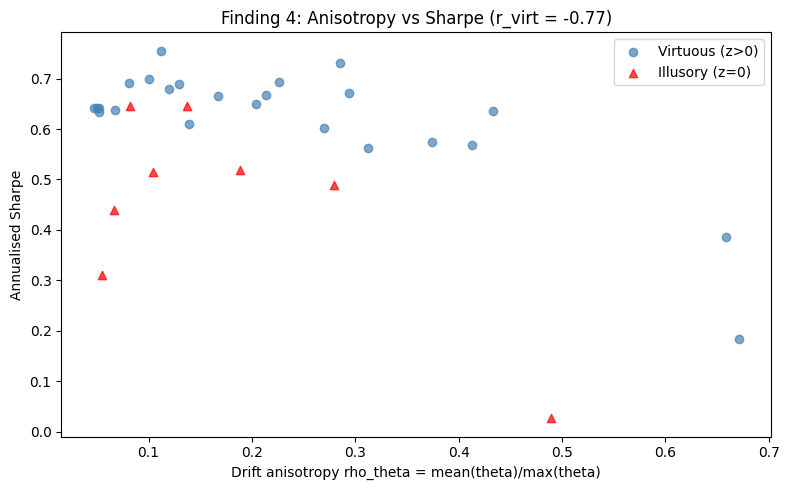

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

# Virtuous regime only (z > 0)
mask_virt = ~df_results.index.get_level_values('z').str.contains('0e\\+00')
virt = df_results[mask_virt].dropna(subset=['anisotropy'])
illu = df_results[~mask_virt].dropna(subset=['anisotropy'])

ax.scatter(virt['anisotropy'], virt['avg_sharpe'], c='steelblue',
           label='Virtuous (z>0)', alpha=0.7)
ax.scatter(illu['anisotropy'], illu['avg_sharpe'], c='red', marker='^',
           label='Illusory (z=0)', alpha=0.7)

if len(virt) > 3:
    r = virt[['anisotropy', 'avg_sharpe']].corr().iloc[0, 1]
    ax.set_title(f'Finding 4: Anisotropy vs Sharpe (r_virt = {r:.2f})')
else:
    ax.set_title('Finding 4: Anisotropy vs Sharpe')

ax.set_xlabel('Drift anisotropy rho_theta = mean(theta)/max(theta)')
ax.set_ylabel('Annualised Sharpe')
ax.legend()
plt.tight_layout()
plt.show()

### Finding 8: Goldilocks zone — Sharpe vs d_proj

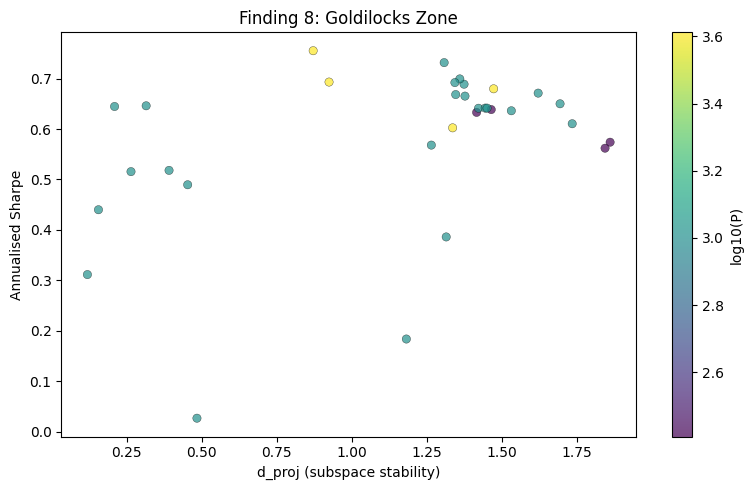

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(
    df_results['avg_subspace_stability'],
    df_results['avg_sharpe'],
    c=np.log10(df_results.index.get_level_values('P').astype(float)),
    cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.3,
)
plt.colorbar(sc, label='log10(P)')
ax.set_xlabel('d_proj (subspace stability)')
ax.set_ylabel('Annualised Sharpe')
ax.set_title('Finding 8: Goldilocks Zone')
plt.tight_layout()
plt.show()

---
## 5. Summary correlation table

In [15]:
cols = ['avg_subspace_stability', 'avg_max_principal_angle',
        'avg_mean_principal_angle', 'avg_erank', 'avg_spectral_gap', 'anisotropy']

mask_virt = ~df_results.index.get_level_values('z').str.contains('0e\\+00')

corr_all  = df_results[cols + ['avg_sharpe']].corr()['avg_sharpe'].drop('avg_sharpe')
corr_virt = df_results.loc[mask_virt, cols + ['avg_sharpe']].corr()['avg_sharpe'].drop('avg_sharpe')

df_corr = pd.DataFrame({'All data': corr_all, 'Virtuous (z>0)': corr_virt})
print("\n=== Metric-Sharpe Correlations ===")
print(df_corr.round(3))


=== Metric-Sharpe Correlations ===
                          All data  Virtuous (z>0)
avg_subspace_stability       0.406          -0.041
avg_max_principal_angle      0.445           0.198
avg_mean_principal_angle    -0.202          -0.713
avg_erank                    0.606           0.625
avg_spectral_gap            -0.447          -0.810
anisotropy                  -0.546          -0.770


## 6. Full results table for paper Section 8

In [16]:
top = df_results.nlargest(10, 'avg_sharpe')[[
    'avg_sharpe', 'avg_spectral_gap', 'avg_erank', 'avg_subspace_stability', 'anisotropy'
]]
print("\n=== Top 10 Configurations by Sharpe ===")
print(top.round(4))


=== Top 10 Configurations by Sharpe ===
                 avg_sharpe  avg_spectral_gap  avg_erank  \
k  P    z                                                  
24 4096 z=1e+01      0.7554            0.0008    15.5315   
12 1024 z=1e+01      0.7318            0.2780    11.0687   
28 1024 z=1e+01      0.6995            0.0000    19.5351   
12 4096 z=1e+01      0.6933            0.1633    10.5465   
32 1024 z=1e+01      0.6922            0.0000    19.7265   
24 1024 z=1e+01      0.6890            0.0088    18.8906   
   4096 z=5e+01      0.6799            0.0180    19.2916   
12 1024 z=5e+01      0.6713            0.2962    11.1162   
16 1024 z=1e+01      0.6685            0.1828    14.2030   
20 1024 z=1e+01      0.6654            0.0900    16.9558   

                 avg_subspace_stability  anisotropy  
k  P    z                                            
24 4096 z=1e+01                  0.8712      0.1120  
12 1024 z=1e+01                  1.3080      0.2855  
28 1024 z=1e+01       

# Extra sweeps for smoother plots

In [17]:
# ============================================================
# Sweep C — Smoother z curve (Finding 5: metrics co-move with z)
# Fix k=12, P=1024, sweep z with finer resolution
# Jobs: 1 k × 7 z × 1 seed = 7 jobs (all fast, P=1024)
# ============================================================
P_C = [1024]
K_C = [12]
Z_C = [0, 1, 5, 10, 20, 50, 100]

rff_C = rff_A   # reuse P=1024 RFF from Sweep A
jobs_C = build_jobs(rff_C, K_C, P_C, Z_C, NUM_ITER_RFF, WINDOW_LEN)
print(f"Sweep C: {len(jobs_C)} jobs (k=12, P=1024, fine z grid)")

raw_C = run_sweep(jobs_C, verbose=True)
agg_C = aggregate(raw_C)
df_C  = make_results_df(agg_C)

print(f"\nSweep C done. Shape: {df_C.shape}")
df_C[['avg_sharpe', 'avg_subspace_stability', 'avg_max_principal_angle', 'avg_erank']].round(4)

Sweep C: 7 jobs (k=12, P=1024, fine z grid)
Dispatching 7 jobs across 7 workers (cost range 42567–42567, LPT order) ...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   1 out of   7 | elapsed: 57.0min remaining: 342.2min
[Parallel(n_jobs=7)]: Done   2 out of   7 | elapsed: 122.8min remaining: 306.9min
[Parallel(n_jobs=7)]: Done   3 out of   7 | elapsed: 123.1min remaining: 164.1min
[Parallel(n_jobs=7)]: Done   4 out of   7 | elapsed: 123.1min remaining: 92.4min
[Parallel(n_jobs=7)]: Done   5 out of   7 | elapsed: 123.2min remaining: 49.3min



Sweep C done. Shape: (7, 9)


[Parallel(n_jobs=7)]: Done   7 out of   7 | elapsed: 123.2min finished


avg_sharpe  avg_subspace_stability  avg_max_principal_angle  \
k  P    z                                                                      
12 1024 z=0e+00      0.3692                  0.3928                   0.2589   
        z=1e+00      0.7635                  0.8101                   0.5202   
        z=1e+01      0.6978                  1.3063                   0.7433   
        z=1e+02      0.6419                  1.6727                   1.0065   
        z=2e+01      0.6808                  1.4933                   0.8450   
        z=5e+00      0.6510                  1.1061                   0.6711   
        z=5e+01      0.6701                  1.6248                   0.9439   

                 avg_erank  
k  P    z                   
12 1024 z=0e+00     8.8251  
        z=1e+00    10.1014  
        z=1e+01    11.0694  
        z=1e+02    11.1041  
        z=2e+01    11.1029  
        z=5e+00    10.9317  
        z=5e+01    11.1159

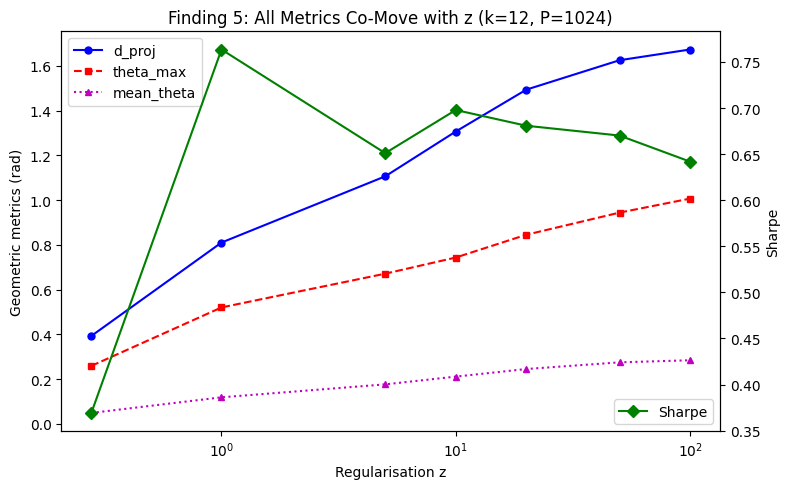

In [18]:
# ── Finding 5 (smooth): All metrics co-move with z ──────────
metrics_z = []
for z_val in Z_C:
    z_lab = _z_label(z_val)
    try:
        row = df_C.loc[(12, 1024, z_lab)]
        metrics_z.append({
            'z': max(z_val, 0.5),  # shift 0 slightly for log scale
            'Sharpe': row['avg_sharpe'],
            'd_proj': row['avg_subspace_stability'],
            'theta_max': row['avg_max_principal_angle'],
            'mean_theta': row['avg_mean_principal_angle'],
        })
    except KeyError:
        pass

df_z = pd.DataFrame(metrics_z).set_index('z')
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

ax1.plot(df_z.index, df_z['d_proj'], 'o-b', label='d_proj', markersize=5)
ax1.plot(df_z.index, df_z['theta_max'], 's--r', label='theta_max', markersize=5)
ax1.plot(df_z.index, df_z['mean_theta'], '^:m', label='mean_theta', markersize=5)
ax2.plot(df_z.index, df_z['Sharpe'], 'D-g', label='Sharpe', markersize=6)

ax1.set_xlabel('Regularisation z')
ax1.set_xscale('symlog', linthresh=1)  # handles z=0 gracefully
ax1.set_ylabel('Geometric metrics (rad)')
ax2.set_ylabel('Sharpe')
ax1.set_title(f'Finding 5: All Metrics Co-Move with z (k=12, P=1024)')
ax1.legend(loc='upper left'); ax2.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# Sweep D — Smoother P curve (Findings 1 & 2: Virtue of Complexity)
# Fix k ∈ {12, 24}, z=10, sweep P with finer resolution
# Jobs: 2 k × 6 P × 1 z × 1 seed = 12 jobs
# ============================================================
P_D = [128, 256, 512, 1024, 2048, 4096]
K_D = [12, 24]
Z_D = [10]

rff_D = build_rff_inputs(X_chars, df_synth, P_D, NUM_ITER_RFF, GAMMA, RandomFourierFeatures)
jobs_D = build_jobs(rff_D, K_D, P_D, Z_D, NUM_ITER_RFF, WINDOW_LEN)
print(f"Sweep D: {len(jobs_D)} jobs (k in {{12,24}}, z=10, fine P grid)")

raw_D = run_sweep(jobs_D, verbose=True)
agg_D = aggregate(raw_D)
df_D  = make_results_df(agg_D)

print(f"\nSweep D done. Shape: {df_D.shape}")
df_D[['avg_sharpe', 'avg_r2_oos']].round(4)

Sweep D: 12 jobs (k in {12,24}, z=10, fine P grid)
Dispatching 12 jobs across 7 workers (cost range 5321–481589, LPT order) ...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   1 out of  12 | elapsed: 102.1min remaining: 1123.1min
[Parallel(n_jobs=7)]: Done   3 out of  12 | elapsed: 143.4min remaining: 430.1min
[Parallel(n_jobs=7)]: Done   5 out of  12 | elapsed: 193.4min remaining: 270.8min
[Parallel(n_jobs=7)]: Done   7 out of  12 | elapsed: 204.0min remaining: 145.7min
[Parallel(n_jobs=7)]: Done   9 out of  12 | elapsed: 264.7min remaining: 88.2min
[Parallel(n_jobs=7)]: Done  12 out of  12 | elapsed: 281.5min finished



Sweep D done. Shape: (12, 9)


avg_sharpe  avg_r2_oos
k  P    z                              
12 128  z=1e+01      0.5411     -0.0287
   256  z=1e+01      0.5917     -0.0180
   512  z=1e+01      0.5920     -0.0135
   1024 z=1e+01      0.7228     -0.0068
   2048 z=1e+01      0.6495     -0.0083
   4096 z=1e+01      0.6787     -0.0074
24 128  z=1e+01      0.6742     -0.0137
   256  z=1e+01      0.6415     -0.0075
   512  z=1e+01      0.6628     -0.0037
   1024 z=1e+01      0.6863     -0.0018
   2048 z=1e+01      0.7180     -0.0019
   4096 z=1e+01      0.7337     -0.0034

In [2]:
# ── Findings 1 & 2 (smooth): Sharpe & R² increase with P ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for k_val in K_D:
    try:
        sub = df_D.xs(_z_label(10), level='z').xs(k_val, level='k')
        axes[0].plot(sub.index, sub['avg_sharpe'], 'o-', label=f'k={k_val}, z=10', markersize=5)
        axes[1].plot(sub.index, sub['avg_r2_oos'], 'o-', label=f'k={k_val}, z=10', markersize=5)
    except KeyError:
        pass

axes[0].set_xlabel('RFF dimension P'); axes[0].set_ylabel('Annualised Sharpe')
axes[0].set_title('Finding 1: Sharpe increases with P'); axes[0].legend()
axes[0].set_xscale('log')

axes[1].set_xlabel('RFF dimension P'); axes[1].set_ylabel('OOS R2')
axes[1].set_title('Finding 2: R2 increases with P'); axes[1].legend()
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

### Averaging out RFF noise

In [21]:
# ============================================================
# Sweep D2 — Cleaner P curves with RFF seed averaging
# Fix k ∈ {12, 24}, z ∈ {10, 20}, sweep P, 3 RFF seeds
# Jobs: 2 k × 6 P × 2 z × 3 seeds = 72 jobs
#   but P ∈ {128,256,512} are fast; bulk of time is 2048/4096
# ============================================================
P_D2 = [128, 256, 512, 1024, 2048, 4096]
K_D2 = [12, 24]
Z_D2 = [10, 20]
SEEDS_D2 = 3    # average over 3 RFF draws to smooth Sharpe

rff_D2 = build_rff_inputs(X_chars, df_synth, P_D2, SEEDS_D2, GAMMA, RandomFourierFeatures)
jobs_D2 = build_jobs(rff_D2, K_D2, P_D2, Z_D2, SEEDS_D2, WINDOW_LEN)
print(f"Sweep D2: {len(jobs_D2)} jobs (k∈{{12,24}}, z∈{{10,20}}, 6 P-values, 3 seeds)")

raw_D2 = run_sweep(jobs_D2, verbose=True)
agg_D2 = aggregate(raw_D2)
df_D2  = make_results_df(agg_D2)

print(f"\nSweep D2 done. Shape: {df_D2.shape}")
df_D2[['avg_sharpe', 'avg_r2_oos']].round(4)

Sweep D2: 72 jobs (k∈{12,24}, z∈{10,20}, 6 P-values, 3 seeds)
Dispatching 72 jobs across 7 workers (cost range 5321–481589, LPT order) ...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   1 out of  72 | elapsed: 936.2min remaining: 66469.7min
[Parallel(n_jobs=7)]: Done   9 out of  72 | elapsed: 1427.3min remaining: 9991.4min


KeyboardInterrupt: 

NameError: name 'df_D2' is not defined

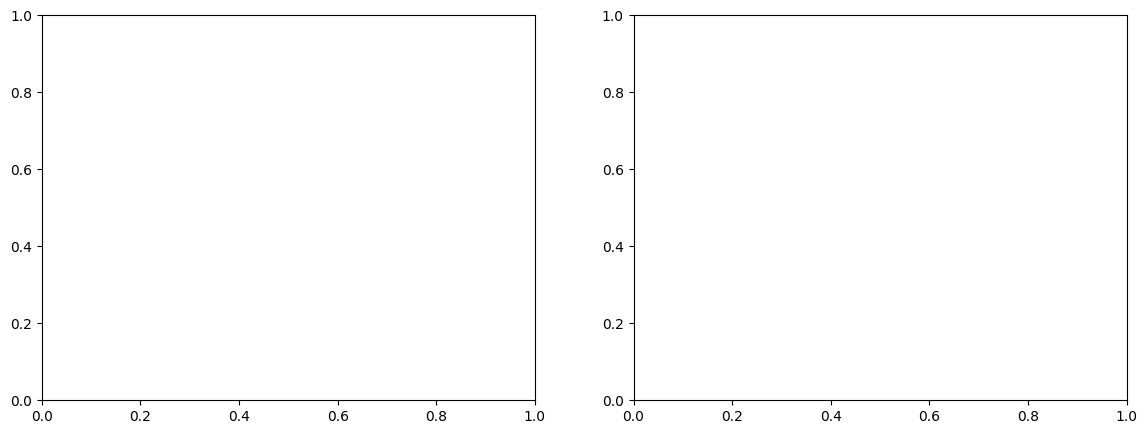

In [5]:
# ── Findings 1 & 2 (seed-averaged): Sharpe & R² vs P ────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

styles = {
    (12, 10): ('o-', 'steelblue'),
    (12, 20): ('s--', 'royalblue'),
    (24, 10): ('o-', 'darkorange'),
    (24, 20): ('s--', 'orangered'),
}

for (k_val, z_val), (ls, col) in styles.items():
    z_lab = _z_label(z_val)
    try:
        sub = df_D2.xs(z_lab, level='z').xs(k_val, level='k')
        axes[0].plot(sub.index, sub['avg_sharpe'], ls, color=col,
                     label=f'k={k_val}, z={z_val}', markersize=5)
        axes[1].plot(sub.index, sub['avg_r2_oos'], ls, color=col,
                     label=f'k={k_val}, z={z_val}', markersize=5)
    except KeyError:
        pass

axes[0].set_xlabel('RFF dimension P'); axes[0].set_ylabel('Annualised Sharpe')
axes[0].set_title('Finding 1: Sharpe increases with P (3-seed avg)'); axes[0].legend()
axes[0].set_xscale('log')

axes[1].set_xlabel('RFF dimension P'); axes[1].set_ylabel('OOS R²')
axes[1].set_title('Finding 2: R² increases with P (3-seed avg)'); axes[1].legend()
axes[1].set_xscale('log')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Sweep D2 — Cleaner P curves with RFF seed averaging
# Fix k ∈ {12, 24}, z ∈ {10, 20}, sweep P, 3 RFF seeds
# Jobs: 2 k × 6 P × 2 z × 3 seeds = 72 jobs
#   but P ∈ {128,256,512} are fast; bulk of time is 2048/4096
# ============================================================
P_D2 = [128, 256, 512, 1024, 2048, 4096]
K_D2 = [12, 24]
Z_D2 = [10]
SEEDS_D2 = 1    # average over 1 RFF draw to smooth Sharpe

rff_D2 = build_rff_inputs(X_chars, df_synth, P_D2, SEEDS_D2, GAMMA, RandomFourierFeatures)
jobs_D2 = build_jobs(rff_D2, K_D2, P_D2, Z_D2, SEEDS_D2, WINDOW_LEN)
print(f"Sweep D2: {len(jobs_D2)} jobs (k∈{{12,24}}, z∈{{10,20}}, 6 P-values, 1 seed)")

raw_D2 = run_sweep(jobs_D2, verbose=True)
agg_D2 = aggregate(raw_D2)
df_D2  = make_results_df(agg_D2)

print(f"\nSweep D2 done. Shape: {df_D2.shape}")
df_D2[['avg_sharpe', 'avg_r2_oos']].round(4)

Sweep D2: 12 jobs (k∈{12,24}, z∈{10,20}, 6 P-values, 1 seed)
Dispatching 12 jobs across 7 workers (cost range 5321–481589, LPT order) ...


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   1 out of  12 | elapsed: 158.8min remaining: 1746.5min
[Parallel(n_jobs=7)]: Done   3 out of  12 | elapsed: 192.9min remaining: 578.7min


In [1]:
#average the smaller rffs  if needed in the next run